In [18]:
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
data=pd.read_csv("/content/icecream_sales_large.csv")

In [20]:
data.head()

,date,product,price,quantity,weather,day,discount,revenue
0,2026-03-01,Vanilla,100,44,Rainy,Sunday,0,4400
1,2026-03-01,Chocolate,120,22,Rainy,Sunday,0,2640
2,2026-03-01,Strawberry,110,31,Cold,Sunday,0,3410
3,2026-03-01,Mint,105,76,Hot,Sunday,0,7980
4,2026-03-01,Mango,96,73,Hot,Sunday,1,7008


In [21]:
data.tail()

,date,product,price,quantity,weather,day,discount,revenue
145,2026-03-30,Vanilla,85,86,Hot,Monday,1,7310
146,2026-03-30,Chocolate,120,81,Hot,Monday,0,9720
147,2026-03-30,Strawberry,97,31,Rainy,Monday,1,3007
148,2026-03-30,Mint,105,60,Hot,Monday,0,6300
149,2026-03-30,Mango,99,86,Hot,Monday,1,8514


In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      150 non-null    object
 1   product   150 non-null    object
 2   price     150 non-null    int64 
 3   quantity  150 non-null    int64 
 4   weather   150 non-null    object
 5   day       150 non-null    object
 6   discount  150 non-null    int64 
 7   revenue   150 non-null    int64 
dtypes: int64(4), object(4)
memory usage: 9.5+ KB


In [23]:
data.describe()

,price,quantity,discount,revenue
count,150.000000,150.000000,150.000000,150.000000
mean,103.913333,55.373333,0.420000,5725.766667
std,10.491887,22.690668,0.495212,2374.833045
min,81.000000,11.000000,0.000000,1056.000000
25%,96.000000,34.250000,0.000000,3612.000000
50%,104.500000,58.500000,0.000000,5987.000000
75%,110.000000,76.750000,1.000000,7905.750000
max,120.000000,99.000000,1.000000,10800.000000


In [24]:
data.isna().sum()

,0
date,0
product,0
price,0
quantity,0
weather,0
day,0
discount,0
revenue,0


In [25]:
data.duplicated().sum()

np.int64(0)

In [26]:
product_sales=data.groupby("product")["revenue"].sum().sort_values(ascending=False).reset_index()
print(product_sales)#identified the product that earns more revenue(makes the most money)

      product  revenue
0   Chocolate   183742
1  Strawberry   172425
2       Mango   170914
3        Mint   170613
4     Vanilla   161171


In [27]:
top_selling=data.groupby("product")["quantity"].sum().sort_values(ascending=False).reset_index()
print(top_selling)#mint is the highest selling product

      product  quantity
0        Mint      1744
1     Vanilla      1722
2  Strawberry      1652
3   Chocolate      1603
4       Mango      1585


In [28]:
day_sales = data.groupby("day")["revenue"].sum().sort_values(ascending=False)
print(day_sales)#day that makes more money

day
Monday       154282
Thursday     135248
Sunday       124703
Wednesday    115803
Tuesday      114458
Saturday     109769
Friday       104602
Name: revenue, dtype: int64


In [29]:
productperday = data.groupby(["day","product"])["revenue"].sum().unstack()
print(productperday)#how much each product makes per day

product    Chocolate  Mango   Mint  Strawberry  Vanilla
day                                                    
Friday         22051  22300  22299       19752    18200
Monday         32640  31205  31540       31887    27010
Saturday       24010  20059  25977       22235    17488
Sunday         21269  35001  25756       19620    23057
Thursday       30056  21455  24501       25405    33831
Tuesday        29320  18329  21325       26400    19084
Wednesday      24396  22565  19215       27126    22501


In [30]:
best_product_each_day = productperday.idxmax(axis=1)
print(best_product_each_day)#money

day
Friday            Mango
Monday        Chocolate
Saturday           Mint
Sunday            Mango
Thursday        Vanilla
Tuesday       Chocolate
Wednesday    Strawberry
dtype: object


In [36]:
day_quantity = data.groupby("day")["quantity"].sum().sort_values(ascending=False)
print(day_quantity)#day with most quantity sales

day
Monday       1476
Thursday     1314
Sunday       1199
Wednesday    1127
Tuesday      1111
Saturday     1073
Friday       1006
Name: quantity, dtype: int64


In [31]:
productsalesperday = data.groupby(["day","product"])["quantity"].sum().unstack()
print(productsalesperday)#quantity per day

product    Chocolate  Mango  Mint  Strawberry  Vanilla
day                                                   
Friday           189    213   224         190      190
Monday           272    288   328         305      283
Saturday         212    188   267         222      184
Sunday           197    328   252         183      239
Thursday         261    192   248         250      363
Tuesday          257    165   229         240      220
Wednesday        215    211   196         262      243


In [32]:
best_productsales_each_day = productsalesperday.idxmax(axis=1)
print(best_productsales_each_day)#highest quantity per day

day
Friday             Mint
Monday             Mint
Saturday           Mint
Sunday            Mango
Thursday        Vanilla
Tuesday       Chocolate
Wednesday    Strawberry
dtype: object


In [33]:
data.groupby("product")[["quantity", "revenue"]].sum().sort_values(by="revenue",ascending=False)

,quantity,revenue
product,,
Chocolate,1603,183742
Strawberry,1652,172425
Mango,1585,170914
Mint,1744,170613
Vanilla,1722,161171


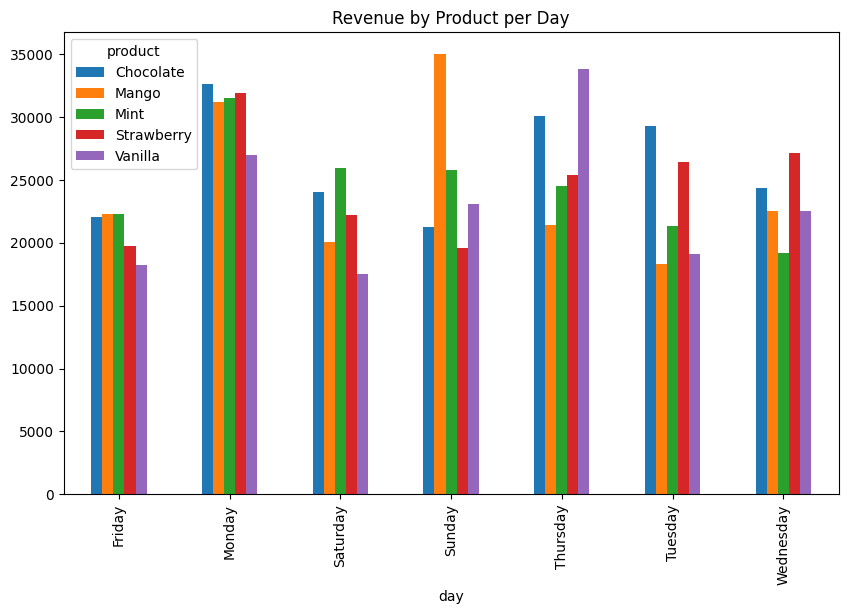

In [34]:
import matplotlib.pyplot as plt

productperday.plot(kind="bar", figsize=(10,6))
plt.title("Revenue by Product per Day")
plt.show()